# Analyse du dataset GUIDE — Microsoft Security Incident Prediction

**Source :** https://www.kaggle.com/datasets/Microsoft/microsoft-security-incident-prediction

**Objectif :** Classifier les incidents de cybersécurité en 3 classes : `TruePositive (TP)`, `BenignPositive (BP)`, `FalsePositive (FP)`


### Plan du notebook
1. Chargement & échantillonnage
    * 1.1. Chargement
    * 1.2.  Échantillonnage
2. Traitement des données
    * 2.1 Présélection des colonnes 
    * 2.2 Audit et traitement  des Nan's
    * 2.3 Réduction des colonnes à haute cardinalité
    * 2.4 Analyse exploratoire
3. Modélisations
    * 3.1 Encodage et preparation  à la modélisation
4. Interface utilisateur

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
import re
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,f1_score


## 1. Chargement et échantillonnage stratifié

Le fichier original (~2.43 Go) est lu par blocs pour éviter les problèmes de mémoire.
Un échantillon de 1 % est extrait en conservant la distribution de la variable cible `IncidentGrade`.

**Correction apportée :** le paramètre par défaut `cible` pointe maintenant vers `'IncidentGrade'` (était `'y'` — trompeur).

In [2]:
def echantillonner_stratifie(chemin, frac=0.01, cible='IncidentGrade', chemin_sortie='../echantillon.csv'):
    """
    Lit un CSV volumineux par blocs et produit un échantillon stratifié.

    Paramètres
    ----------
    chemin        : chemin vers le CSV source
    frac          : fraction à échantillonner par classe (défaut 1 %)
    cible         : colonne de stratification (défaut 'IncidentGrade')
    chemin_sortie : où sauvegarder l'échantillon
    """
    sample_list = []

    for chunk in pd.read_csv(chemin, chunksize=10_000):
        chunk = chunk.dropna(subset=[cible])
        sample = (
            chunk
            .groupby(cible, group_keys=False)
            .apply(lambda x: x.sample(frac=frac, random_state=2026))
        )
        sample_list.append(sample)

    df_sample = pd.concat(sample_list).reset_index(drop=True)
    df_sample.to_csv(chemin_sortie, index=False)
    print(f'Échantillon sauvegardé : {df_sample.shape[0]:,} lignes, {df_sample.shape[1]} colonnes')
    return df_sample

# Décommenter pour régénérer l'échantillon :
# echantillonner_stratifie('../GUIDE_Train.csv', frac=0.01)

In [3]:
echantillon = pd.read_csv('echantillon.csv', low_memory=False)
print(f'Dimensions brutes : {echantillon.shape[0]:,} lignes x {echantillon.shape[1]} colonnes')
print(echantillon.columns)
echantillon.head()

Dimensions brutes : 94,638 lignes x 45 colonnes
Index(['Id', 'OrgId', 'IncidentId', 'AlertId', 'Timestamp', 'DetectorId',
       'AlertTitle', 'Category', 'MitreTechniques', 'IncidentGrade',
       'ActionGrouped', 'ActionGranular', 'EntityType', 'EvidenceRole',
       'DeviceId', 'Sha256', 'IpAddress', 'Url', 'AccountSid', 'AccountUpn',
       'AccountObjectId', 'AccountName', 'DeviceName', 'NetworkMessageId',
       'EmailClusterId', 'RegistryKey', 'RegistryValueName',
       'RegistryValueData', 'ApplicationId', 'ApplicationName',
       'OAuthApplicationId', 'ThreatFamily', 'FileName', 'FolderPath',
       'ResourceIdName', 'ResourceType', 'Roles', 'OSFamily', 'OSVersion',
       'AntispamDirection', 'SuspicionLevel', 'LastVerdict', 'CountryCode',
       'State', 'City'],
      dtype='object')


,Id,OrgId,IncidentId,AlertId,Timestamp,DetectorId,AlertTitle,Category,MitreTechniques,IncidentGrade,...,ResourceType,Roles,OSFamily,OSVersion,AntispamDirection,SuspicionLevel,LastVerdict,CountryCode,State,City
0,884763264609,21,111280,263403,2024-06-09T11:29:01.000Z,3,4,SuspiciousActivity,NaN,BenignPositive,...,NaN,NaN,5,66,NaN,Suspicious,Suspicious,242,1445,10630
1,515396079824,36,30247,97984,2024-06-05T09:54:14.000Z,10,8,InitialAccess,T1566.001,BenignPositive,...,NaN,NaN,5,66,NaN,NaN,NoThreatsFound,242,1445,10630
2,1511828491965,12,2420,1652,2024-05-23T01:55:44.000Z,16,186,Impact,NaN,BenignPositive,...,NaN,NaN,5,66,NaN,NaN,NaN,242,1445,10630
3,223338304201,38,289307,693576,2024-06-13T12:58:35.000Z,2,2,CommandAndControl,NaN,BenignPositive,...,NaN,NaN,0,0,NaN,Suspicious,Suspicious,242,1445,10630
4,335007450734,26,60218,421825,2024-06-10T07:23:12.000Z,497,539,Discovery,T1069.001;T1069.002,BenignPositive,...,NaN,NaN,5,66,NaN,NaN,NaN,242,1445,10630


## 2. Traitement des données

  ### 2.1 Préselection des colonnes

On conserve les colonnes sémantiquement utiles et on écarte Les identifiants purs (aucune valeur prédictive)

In [4]:
COLONNES_UTILES = [
    'Timestamp',
    'AlertTitle',
    'Category',
    'MitreTechniques',
    'IncidentGrade',      # variable cible
    'ActionGrouped',
    'ActionGranular',
    'EntityType',
    'ThreatFamily',
    'ResourceType',
    'Roles',
    'EvidenceRole',
    'RegistryValueData',  # sera binarisée
    'OSFamily',
    'OSVersion',
     'AntispamDirection',
    'SuspicionLevel',
    'LastVerdict',
    'CountryCode',
  #  'State',
   # 'City'
]
#state et city dependent de country code, on les supprime

df = echantillon[COLONNES_UTILES].copy()
print(f'Colonnes conservées : {df.shape[1]}')
df['IncidentGrade_bin'] = df['IncidentGrade'].apply(lambda x: 1 if x == 'TruePositive' else 0)
df.drop('IncidentGrade',axis=1,inplace = True)


df['AlertTitle'] = df['AlertTitle'].astype(str)
df['RegistryValueData'] = df['RegistryValueData'].astype(str)
df['OSFamily'] = df['OSFamily'].astype(str)
df['OSVersion'] = df['OSVersion'].astype(str)
df['CountryCode'] = df['CountryCode'].astype(str)
df.info() 
  

Colonnes conservées : 19
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94638 entries, 0 to 94637
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Timestamp          94638 non-null  object
 1   AlertTitle         94638 non-null  object
 2   Category           94638 non-null  object
 3   MitreTechniques    40574 non-null  object
 4   ActionGrouped      43 non-null     object
 5   ActionGranular     43 non-null     object
 6   EntityType         94638 non-null  object
 7   ThreatFamily       724 non-null    object
 8   ResourceType       64 non-null     object
 9   Roles              2284 non-null   object
 10  EvidenceRole       94638 non-null  object
 11  RegistryValueData  94638 non-null  object
 12  OSFamily           94638 non-null  object
 13  OSVersion          94638 non-null  object
 14  AntispamDirection  1793 non-null   object
 15  SuspicionLevel     14371 non-null  object
 16  LastVerdict    

### 2.2 Audit des NaN

In [5]:
nan_df = pd.DataFrame({
    'Colonne': df.columns,
    'NaN': df.isna().sum().values,
    'Pct_NaN': (df.isna().mean() * 100).round(2).values
}).sort_values('Pct_NaN', ascending=False)

print(nan_df.to_string(index=False))

          Colonne   NaN  Pct_NaN
    ActionGrouped 94595    99.95
   ActionGranular 94595    99.95
     ResourceType 94574    99.93
     ThreatFamily 93914    99.23
AntispamDirection 92845    98.11
            Roles 92354    97.59
   SuspicionLevel 80267    84.81
      LastVerdict 72296    76.39
  MitreTechniques 54064    57.13
         OSFamily     0     0.00
      CountryCode     0     0.00
        OSVersion     0     0.00
        Timestamp     0     0.00
RegistryValueData     0     0.00
     EvidenceRole     0     0.00
       AlertTitle     0     0.00
       EntityType     0     0.00
         Category     0     0.00
IncidentGrade_bin     0     0.00


Les valeurs manquantes ne veulent pas necessairement dire que la donnée n'est pas pertinente. Au contraire, c'est peut être un
indicateur qu'il n'y a rien d'anormal. Donc nous n'allons pas supprimer les colonnes avec trop de NAns, de peur de perdre de l'information utile
que renseigne les valeurs présentes

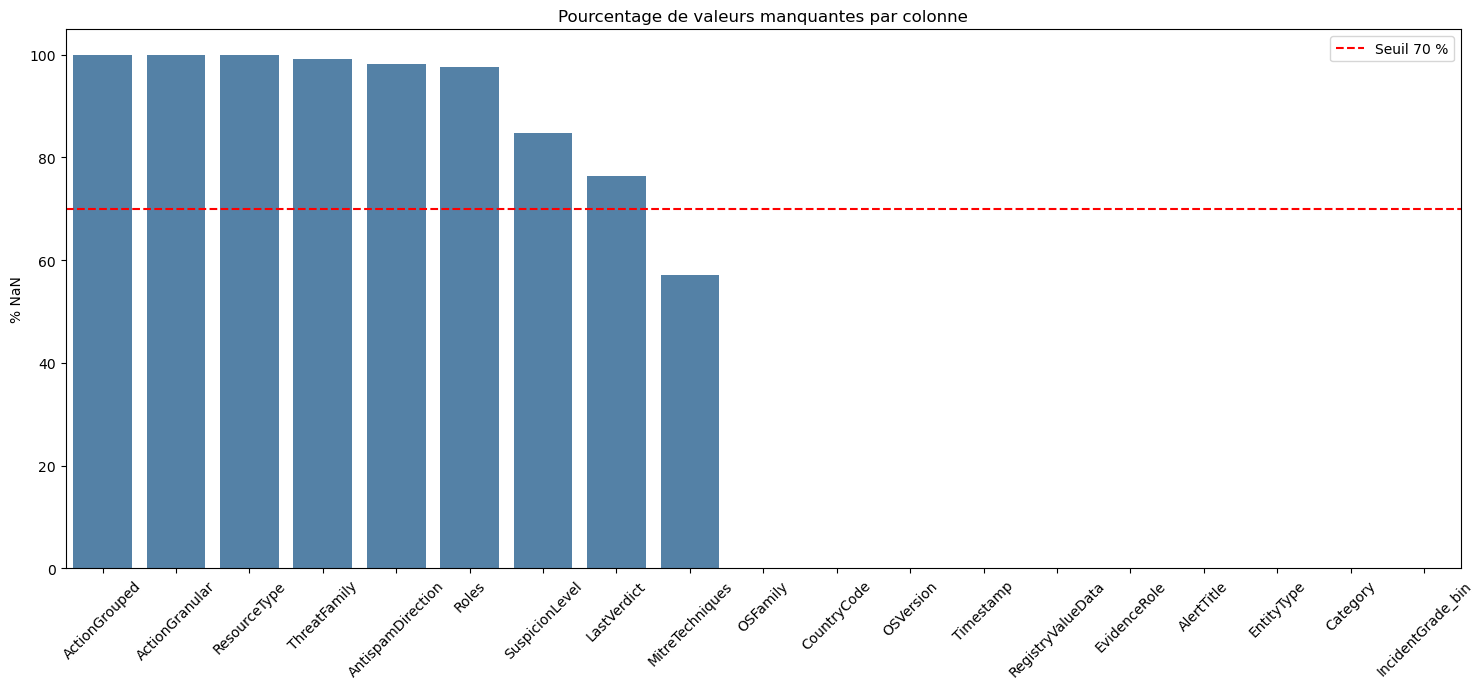

In [6]:
# Visualisation des NaN
fig, ax = plt.subplots(figsize=(15, 7))
sns.barplot(data=nan_df, x='Colonne', y='Pct_NaN', ax=ax, color='steelblue')
ax.axhline(70, color='red', linestyle='--', label='Seuil 70 %')
ax.set_title('Pourcentage de valeurs manquantes par colonne')
ax.set_xlabel('')
ax.set_ylabel('% NaN')
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

### 2.2. Traitement des valeurs manquantes (suite)
| Colonne | Stratégie | Justification |
|---|---|---|
|` ActionGrouped`     | Remplacer par `'Unknown'`             |
|`ActionGranular`     | Remplacer par `'Unknown'`             |
|`ResourceType`       | Remplacer par `'Unknown'`             |
|`ThreatFamily`       | Remplacer par `'Unknown'`             |
|`AntispamDirection`  | Remplacer par `'Unknown'`             |
|`Roles`              | Remplacer par `'Unknown'`             |
| `RegistryValueData` | Binariser --> `HasRegistryData` (0/1) | Haute cardinalité, la présence est informative |
| `MitreTechniques`   | Remplir par `'Unknown'`               | Absence = technique non identifiée |
| `SuspicionLevel`    | Remplir par `'None'`                  | Absence = non évalué / non suspect |
| `LastVerdict`       | Remplir par `'Unknown'`               | Absence = verdict en attente |
| `OSVersion`         | Remplir par `'Unknown'`               | Info manquante fréquente |
| `CountryCode`, `State`, `City` | Remplir par `'Unknown'`    | Données géo incomplètes |
| Lignes sans `IncidentGrade` | Supprimer | Cible indispensable |



In [7]:
# Remplissage des autres colonnes
fill_unknown = ['ActionGrouped','ActionGranular','ResourceType',
                'ThreatFamily','AntispamDirection', 'Roles','RegistryValueData',
                'MitreTechniques', 'LastVerdict', 'OSVersion','CountryCode']
df[fill_unknown] = df[fill_unknown].fillna('Unknown')

df['SuspicionLevel'] = df['SuspicionLevel'].fillna('None')
df['OSFamily'] = df['OSFamily'].fillna('Unknown')

# Vérification
assert df.isna().sum().sum() == 0, 'Il reste des NaN !'
print(f' Aucune valeur manquante. \n Dimensions : {df.shape}')

 Aucune valeur manquante. 
 Dimensions : (94638, 19)


### 2.3  Réduction des colonnes à haute cardinalité

In [8]:
df.nunique().sort_values(ascending=False)

Timestamp            75587
AlertTitle           11069
MitreTechniques        486
ThreatFamily           271
CountryCode            109
RegistryValueData       33
EntityType              23
Category                18
OSVersion               16
ResourceType            11
ActionGranular          10
Roles                    9
LastVerdict              5
OSFamily                 4
AntispamDirection        4
SuspicionLevel           3
ActionGrouped            3
EvidenceRole             2
IncidentGrade_bin        2
dtype: int64

In [9]:
def reduire_cardinalite(series, top_n=20, fill='Other'):
    """Remplace les valeurs hors top_n par fill."""
    top_vals = series.value_counts().head(top_n).index
    return series.where(series.isin(top_vals), other=fill)

df1 = df.copy()


df1['AlertTitle'] = reduire_cardinalite(df['AlertTitle'], top_n=30)
df1['CountryCode'] = reduire_cardinalite(df['CountryCode'], top_n=30)
df1['ThreatFamily'] = reduire_cardinalite(df['ThreatFamily'], top_n=30)


##Timestamp sera traité autrement plustard dans le notebook

print('Cardinalités après réduction :')
for col in ['AlertTitle','CountryCode','ThreatFamily']:
    print(f'  {col} : {df1[col].nunique()} valeurs distinctes')
    

Cardinalités après réduction :
  AlertTitle : 31 valeurs distinctes
  CountryCode : 31 valeurs distinctes
  ThreatFamily : 31 valeurs distinctes


In [10]:
def extraire_technique_principale(val):
    """Extrait le premier identifiant T-xxxx d'une chaîne MITRE."""
    if pd.isna(val) or val == 'Unknown':
        return 'Unknown'
    match = re.search(r'T\d{4}(?:\.\d{3})?', str(val))
    return match.group(0) if match else 'Other'

df['MitreTechniques_Main'] = df['MitreTechniques'].apply(extraire_technique_principale)

# Garder les top 15 techniques + regrouper le reste en 'Other'
TOP_N = 15
top_techniques = df['MitreTechniques_Main'].value_counts().head(TOP_N).index
df1['MitreTechniques'] = df['MitreTechniques_Main'].where(
    df['MitreTechniques_Main'].isin(top_techniques), other='Other'
)

print(f'Techniques distinctes après simplification : {df1["MitreTechniques"].nunique()}')
print(df1['MitreTechniques'].value_counts().head())

Techniques distinctes après simplification : 16
MitreTechniques
Unknown      54064
T1078        14225
T1566.002     8130
T1566         6630
Other         3178
Name: count, dtype: int64


In [11]:
df1.nunique().sort_values(ascending=False)

Timestamp            75587
RegistryValueData       33
CountryCode             31
ThreatFamily            31
AlertTitle              31
EntityType              23
Category                18
MitreTechniques         16
OSVersion               16
ResourceType            11
ActionGranular          10
Roles                    9
LastVerdict              5
OSFamily                 4
AntispamDirection        4
SuspicionLevel           3
ActionGrouped            3
EvidenceRole             2
IncidentGrade_bin        2
dtype: int64

## 2.4. Analyse exploratoire  (EDA)

###  *  Distribution de la variable cible


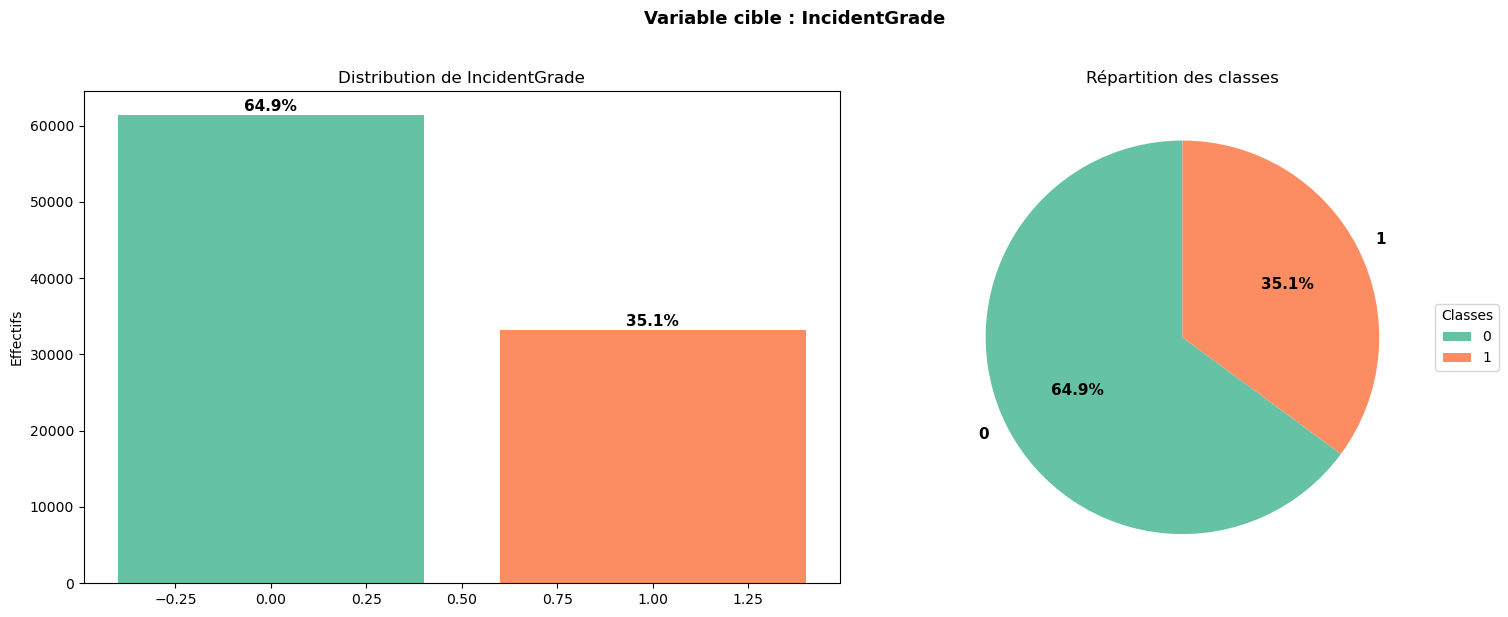

In [12]:
grade_counts = df1['IncidentGrade_bin'].value_counts()
grade_pct    = df1['IncidentGrade_bin'].value_counts(normalize=True) * 100

colors = sns.color_palette('Set2', len(grade_counts))
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].bar(grade_counts.index, grade_counts.values, color=colors)

for i, pct in enumerate(grade_pct.values):
    axes[0].text(i, grade_counts.values[i] + 50, f'{pct:.1f}%', 
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

axes[0].set_title('Distribution de IncidentGrade', fontsize=12)
axes[0].set_xlabel('')
axes[0].set_ylabel('Effectifs')

#Diagramme circulaire
wedges, texts, autotexts = axes[1].pie(
    grade_counts.values,
    labels=grade_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    textprops={'fontsize': 11, 'fontweight': 'bold'}
)

# Légende 
axes[1].legend(wedges, grade_counts.index, title="Classes", loc="center left", bbox_to_anchor=(1, 0.5))
axes[1].set_title('Répartition des classes', fontsize=12)

# Titre
plt.suptitle('Variable cible : IncidentGrade', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### * Analyse bivariée - Features catégorielles vs IncidentGrade

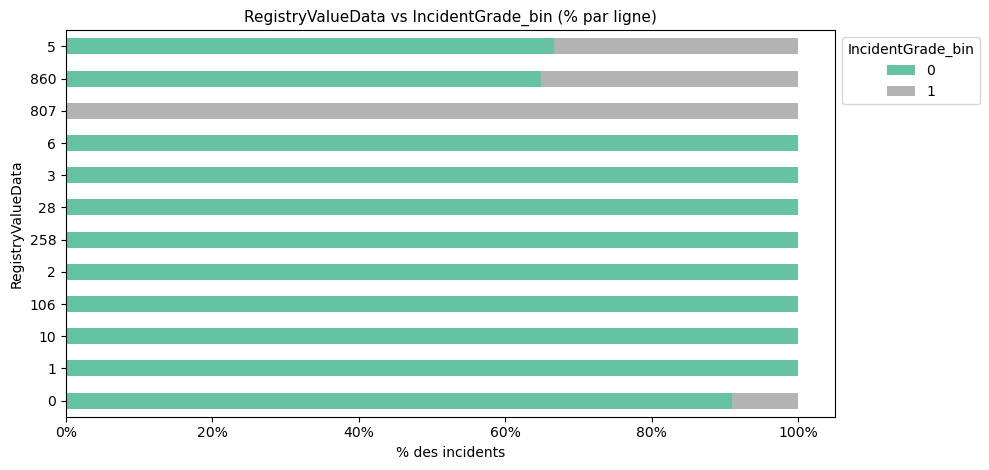

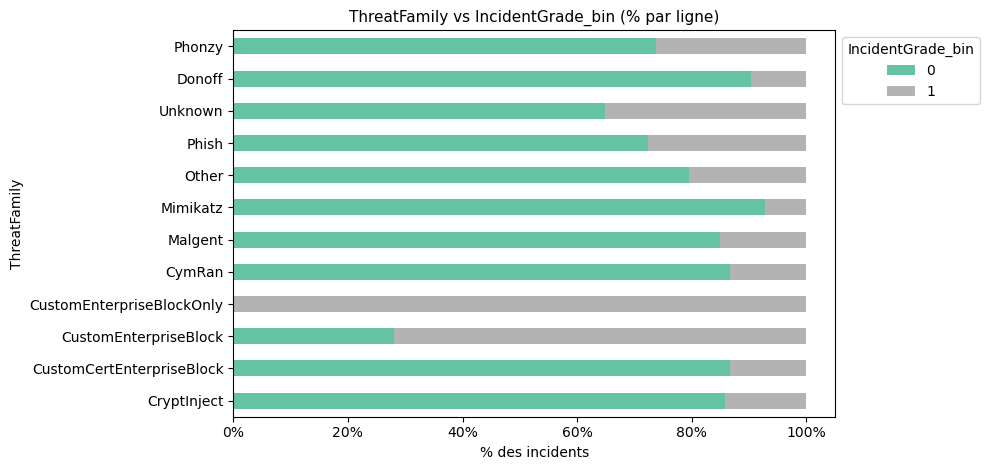

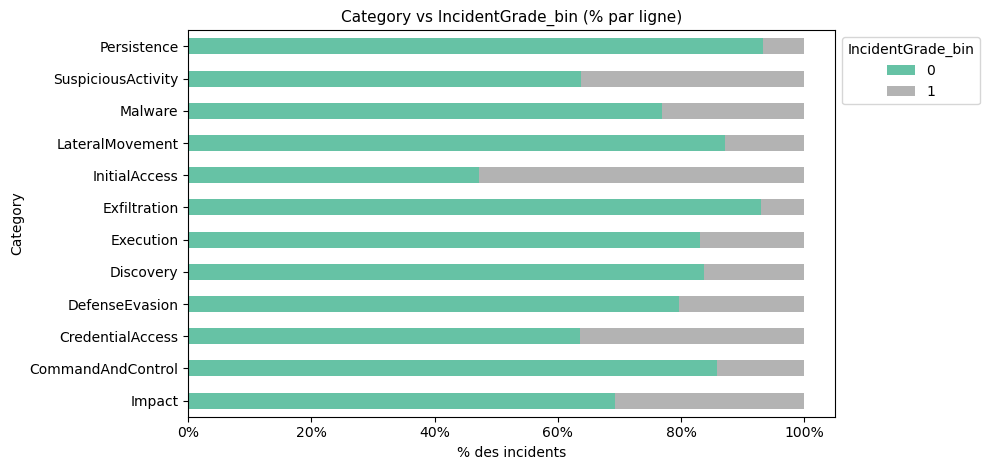

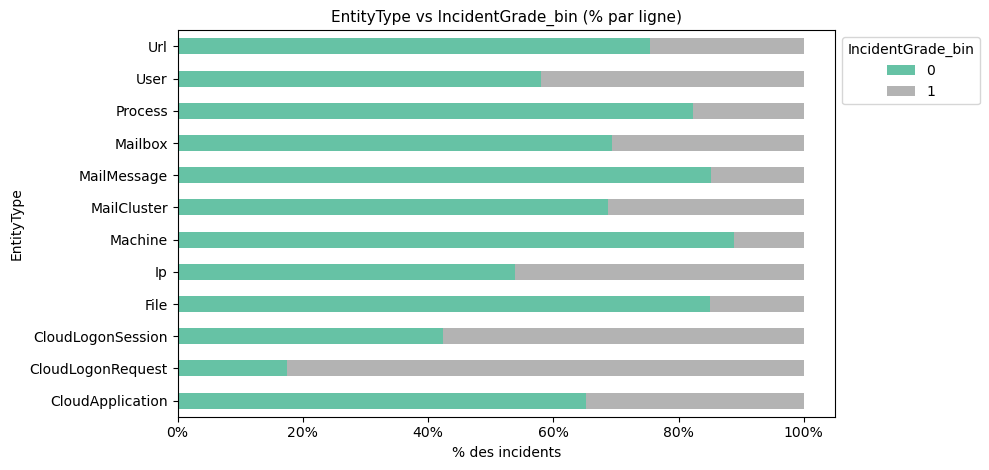

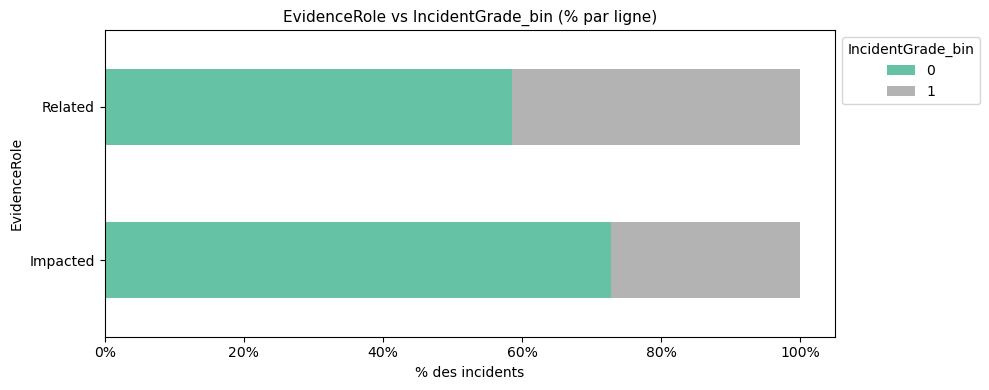

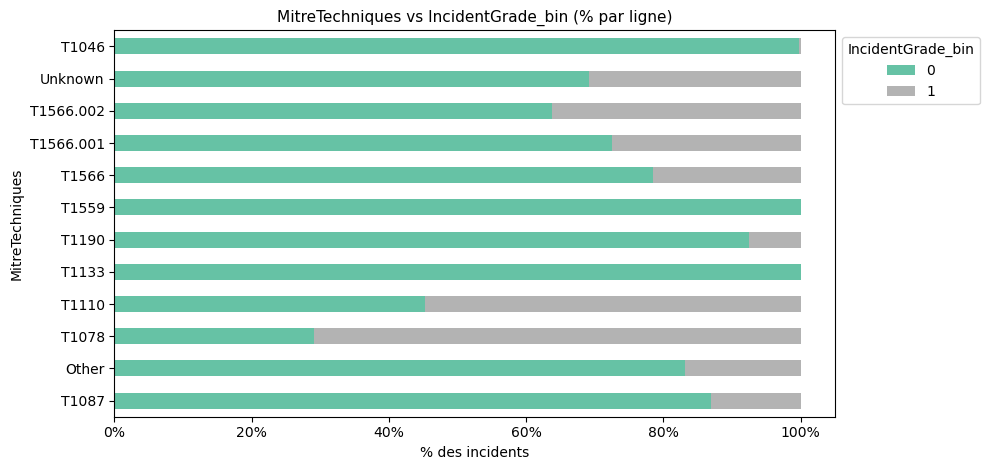

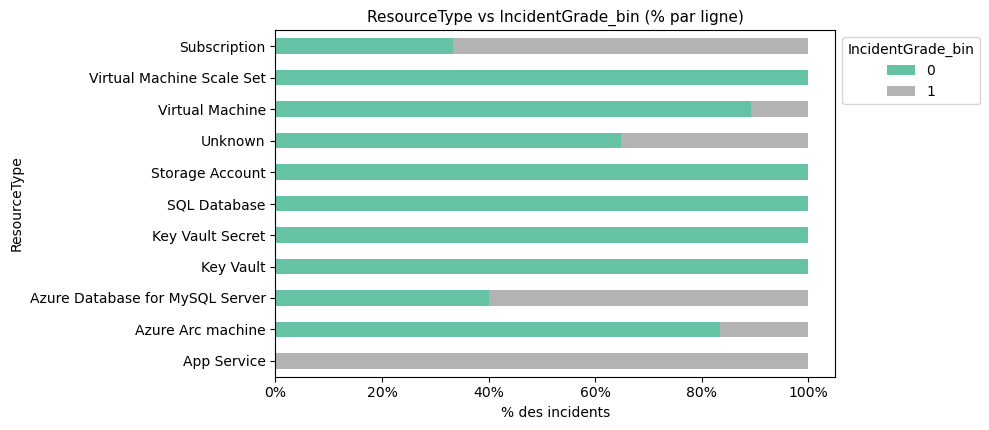

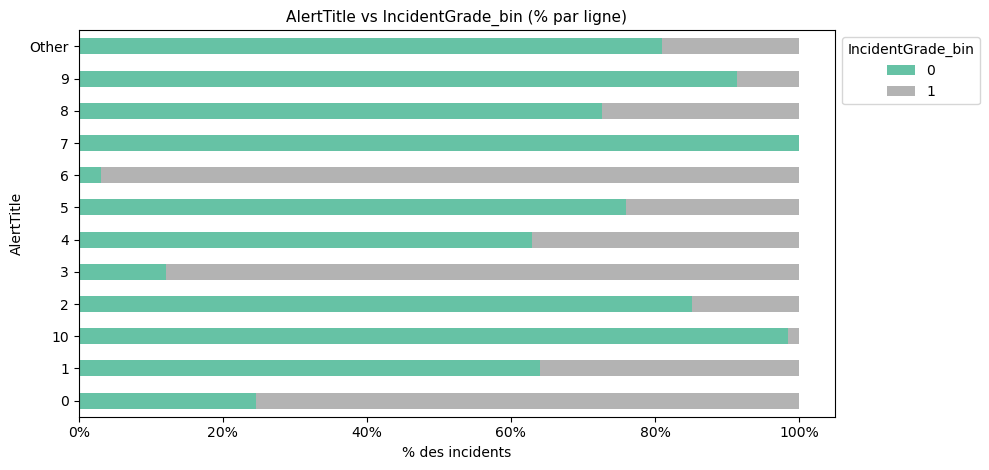

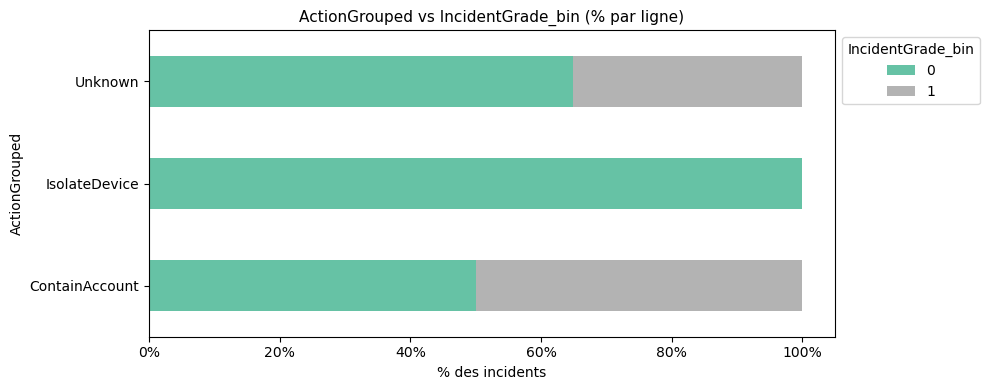

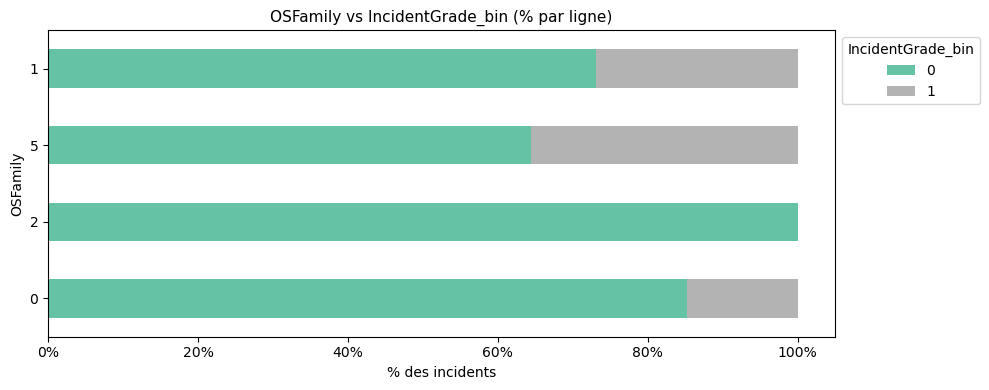

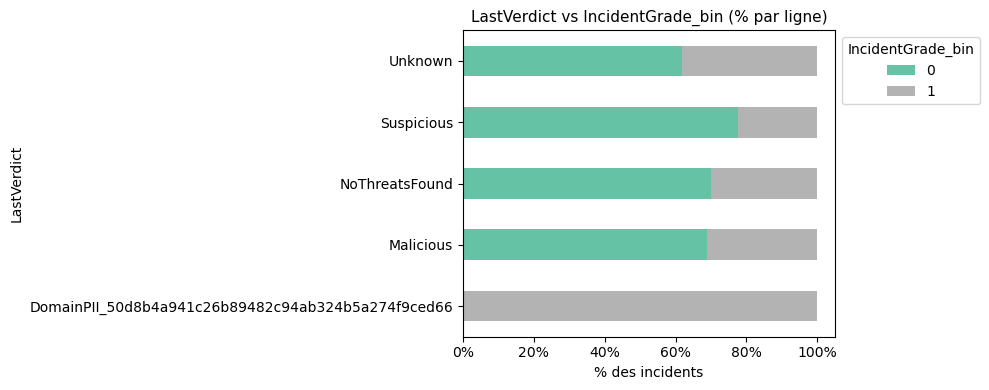

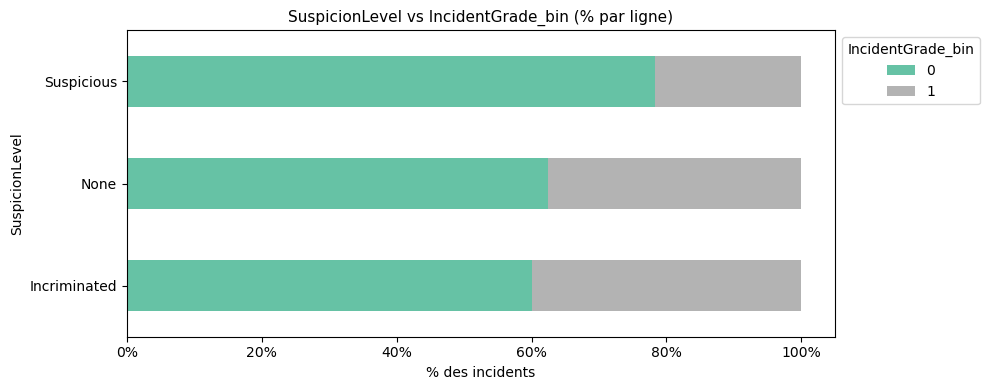

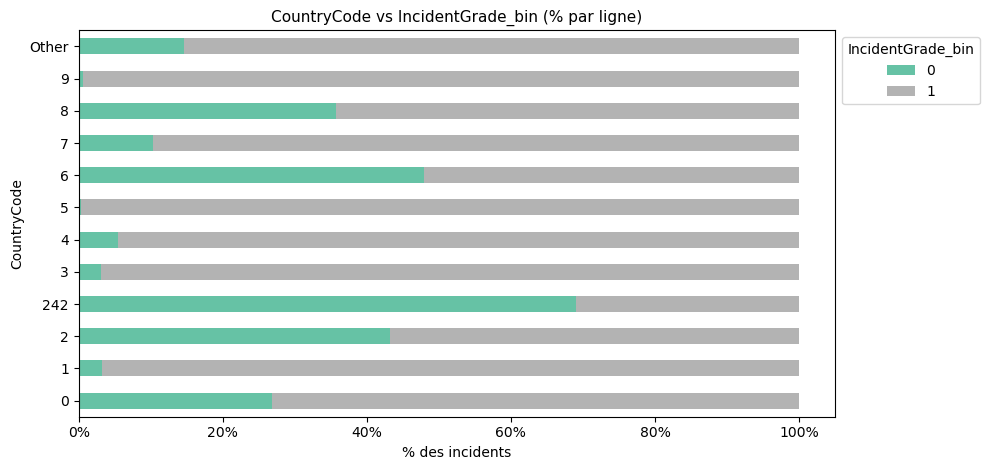

In [13]:
def plot_feature_vs_target(df, feature, target='IncidentGrade_bin', top_n=12):
    """Barplot 100% empilé : distribution du target par modalité de feature."""
    top_vals = df[feature].value_counts().head(top_n).index
    sub = df[df[feature].isin(top_vals)]
    
    ct = pd.crosstab(sub[feature], sub[target], normalize='index') * 100
    ct = ct.loc[ct.sum(axis=1).sort_values(ascending=False).index]

    ax = ct.plot(kind='barh', stacked=True, colormap='Set2', figsize=(10, max(4, len(ct)*0.4)))
    ax.set_title(f'{feature} vs {target} (% par ligne)', fontsize=11)
    ax.set_xlabel('% des incidents')
    ax.legend(title=target, bbox_to_anchor=(1,1))
    ax.xaxis.set_major_formatter(mticker.PercentFormatter())
    plt.tight_layout()
    plt.show()

for feat in ['RegistryValueData','ThreatFamily','Category', 'EntityType', 'EvidenceRole', 'MitreTechniques',
             'ResourceType','AlertTitle','ActionGrouped','OSFamily', 'LastVerdict', 'SuspicionLevel','CountryCode']:
    plot_feature_vs_target(df1, feat)

L'analyse montre que pour certaines variables telles que 'RegistryValueData', 'ThreadFamily' et 'RessourceType', 
Certaines catégories déterminent clairement la nature de  l'incident 

### * Feature engineering

Analyse temporelle

In [14]:
df1.columns

Index(['Timestamp', 'AlertTitle', 'Category', 'MitreTechniques',
       'ActionGrouped', 'ActionGranular', 'EntityType', 'ThreatFamily',
       'ResourceType', 'Roles', 'EvidenceRole', 'RegistryValueData',
       'OSFamily', 'OSVersion', 'AntispamDirection', 'SuspicionLevel',
       'LastVerdict', 'CountryCode', 'IncidentGrade_bin'],
      dtype='object')

Features temporelles créées : ['Hour', 'DayOfWeek', 'DayOfMonth', 'Month', 'IsWeekend', 'IsBusinessHour']


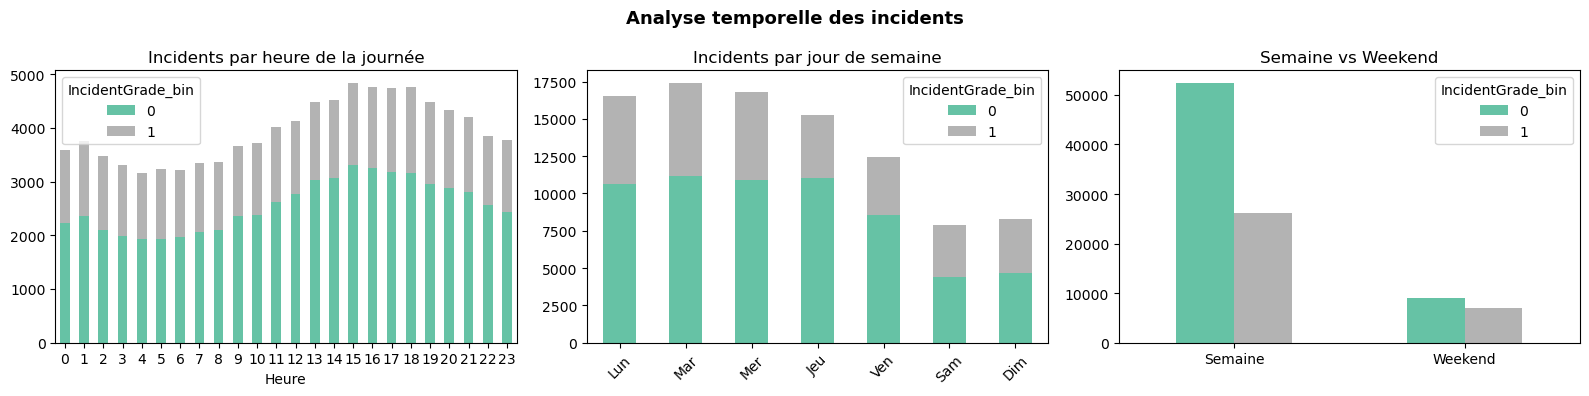

In [15]:
df_original = df1.copy() # on sauvegarde une version pour pouvoir revenir en arriere après les calculs
df2 = df1.copy()

df2['Timestamp'] = pd.to_datetime(df1['Timestamp'], errors='coerce')
df2['Hour']       = df2['Timestamp'].dt.hour
df2['DayOfWeek']  = df2['Timestamp'].dt.dayofweek   # 0=lundi … 6=dimanche
df2['DayOfMonth'] = df2['Timestamp'].dt.day
df2['Month']      = df2['Timestamp'].dt.month
df2['IsWeekend']  = (df2['DayOfWeek'] >= 5).astype(int)
df2['IsBusinessHour'] = df2['Hour'].between(8, 18).astype(int)

print('Features temporelles créées :', ['Hour','DayOfWeek','DayOfMonth','Month','IsWeekend','IsBusinessHour'])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Incidents par heure
hour_grade = df2.groupby(['Hour','IncidentGrade_bin']).size().unstack(fill_value=0)
hour_grade.plot(kind='bar', stacked=True, ax=axes[0], colormap='Set2')
axes[0].set_title('Incidents par heure de la journée')
axes[0].set_xlabel('Heure')
axes[0].tick_params(axis='x', rotation=0)

# Incidents par jour de semaine
jours = ['Lun','Mar','Mer','Jeu','Ven','Sam','Dim']
dow_grade = df2.groupby(['DayOfWeek','IncidentGrade_bin']).size().unstack(fill_value=0)
dow_grade.index = [jours[i] for i in dow_grade.index]
dow_grade.plot(kind='bar', stacked=True, ax=axes[1], colormap='Set2')
axes[1].set_title('Incidents par jour de semaine')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)

# Weekend vs semaine
we_grade = df2.groupby(['IsWeekend','IncidentGrade_bin']).size().unstack(fill_value=0)
we_grade.index = ['Semaine','Weekend']
we_grade.plot(kind='bar', stacked=False, ax=axes[2], colormap='Set2')
axes[2].set_title('Semaine vs Weekend')
axes[2].tick_params(axis='x', rotation=0)

plt.suptitle('Analyse temporelle des incidents', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

On observe un accroissement des activités pendant les heures ouvrables, en semaine. 
Aussi la répartition de la cible suit la même tendance peu importe le moment de la semaine ou de la journée.

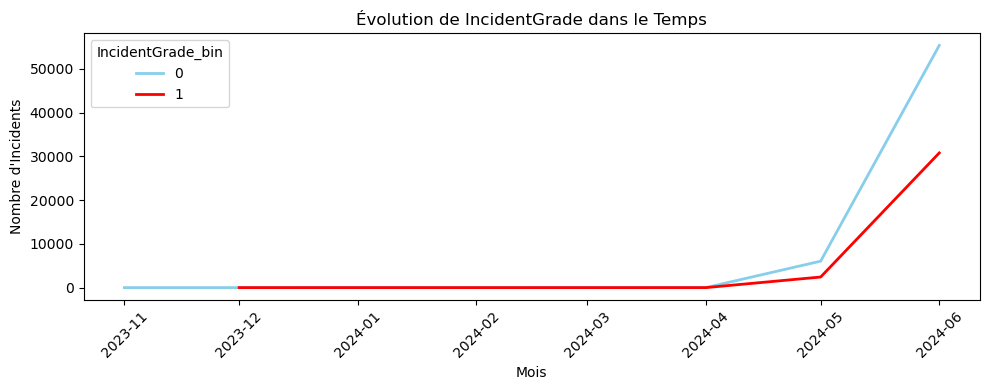

In [16]:
#conversion datetime et nettoyage
df2['Timestamp'] = pd.to_datetime(df1['Timestamp'], errors='coerce')
df2['Timestamp'] = df2['Timestamp'].dt.tz_localize(None)
df2['Month'] = df2['Timestamp'].dt.to_period('M').dt.to_timestamp()
df2['Date'] = df2['Timestamp'].dt.date
df2.drop('Timestamp', axis=1, errors='ignore', inplace=True)

# Agrégation mensuelle par IncidentGrade_bin
incident_grade_monthly = (
    df2.groupby(['Month', 'IncidentGrade_bin'], observed=False)
       .size()
       .reset_index(name='Count')
)

# Couleurs personnalisées
palette = {0: "skyblue", 1: "red"}

# Graphique
plt.figure(figsize=(10, 4))
sns.lineplot(
    data=incident_grade_monthly,
    x='Month',
    y='Count',
    hue='IncidentGrade_bin',
    linewidth=2,
    palette=palette
)

plt.title("Évolution de IncidentGrade dans le Temps")
plt.xlabel("Mois")
plt.ylabel("Nombre d'Incidents")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

interpretation : On remarque que les déclarations d’incidents sont stables durant l’hivers. et le système ne capture que les transactions frauduleuse.

C’est en mai et Juin que se dégagent la majorité des signalements. Possible lien avec tous les mouvements qui se déroulent durant l’été ? c’est une question qu’il faudra explorer.

Faisons un zoom sur les fluxtuations pendant le mois de mai

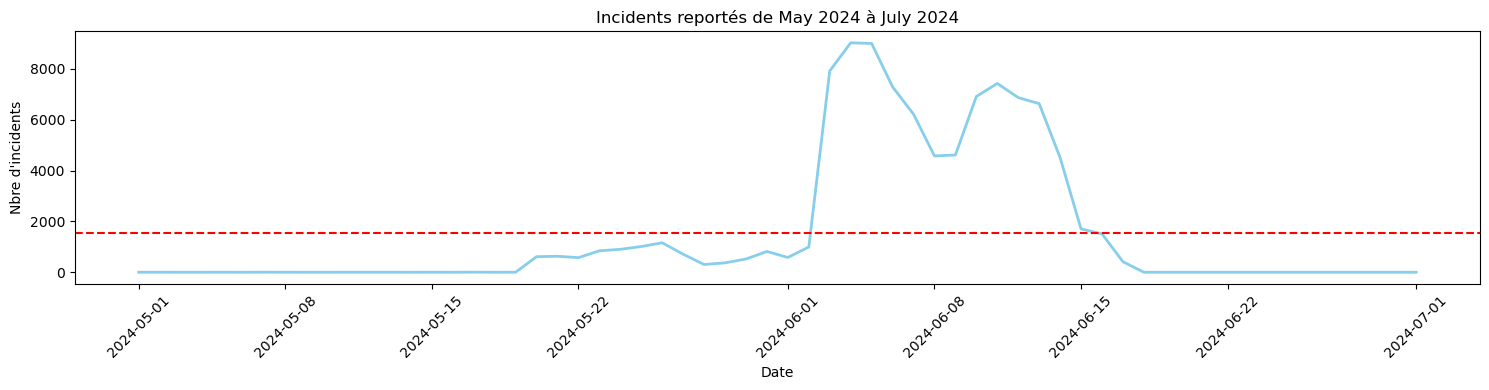

In [17]:
date_debut = pd.to_datetime("2024-05-01").date()
date_fin    = pd.to_datetime("2024-07-01").date()

donnees_filtrees  = df2[(df2['Date'] >= date_debut) & (df2['Date'] <= date_fin )].copy()

toute_date  = pd.date_range(start=date_debut, end=date_fin ).date

decompte_journalier  = (
    donnees_filtrees .groupby('Date')
                 .size()
                 .reindex(toute_date , fill_value=0)
)

df_par_jour  = decompte_journalier .reset_index().rename(columns={'index': 'Date', 0:'Count'})

plt.figure(figsize=(15,4))
sns.lineplot(data=df_par_jour , x='Date', y='Count', color='skyblue', linewidth=2)

plt.axhline(df_par_jour ['Count'].mean(), color='red', linestyle='--')
plt.title(f"Incidents reportés de {date_debut.strftime('%B %Y')} à {date_fin .strftime('%B %Y')}")
plt.xlabel("Date")
plt.ylabel("Nbre d'incidents")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Interprétation :

On observe une augmentation brutale autour du 1er juin , où le nombre d’incidents passe de moins de 2000 à plus de 10_000 en quelques jours du a des activité malveillante. Après le pic début juin, le nombre d’incidents commence à redescendre , avec une apparition notable entre le 6 et le 13 juin.Une tendance clairement baissière après le 15 juin ce qui est  surement  dû à une réponse efficace des équipes de cybersécurité ou une résolution des problèmes détectés début juin. La ligne rouge indique la moyenne du nombre d’incidents sur la période 

## 3. Modélisation 


### * 3.1 Preparation des colonnes pour encodage



In [18]:
df_model = df1.copy()
if 'Timestamp' in df_model.columns:
    df_model['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
    df_model['DayOfWeek']  = df_model['Timestamp'].dt.dayofweek 
    df_model['Hour']       = df_model['Timestamp'].dt.hour
    df_model['Month']       = df_model['Timestamp'].dt.month
    df_model['IsWeekend']  = (df_model['DayOfWeek'] >= 5).astype(int)
    df_model['IsBusinessHour'] = df_model['Hour'].between(8, 18).astype(int)
    df_model.drop('Timestamp', axis=1, errors='ignore', inplace=True)
    df_model.drop('DayOfWeek', axis=1, errors='ignore', inplace=True)
    df_model.drop('Hour', axis=1, errors='ignore', inplace=True)
    
# Encodage de la cible

#df_model['cible'] = np.where(df2['IncidentGrade_bin'] == 1, "Fraude", "Non Fraude")
df_model['cible'] = df_model['IncidentGrade_bin']
df_model = df_model.drop(columns=['IncidentGrade_bin'])
    

for col in ['Month','IsWeekend','IsBusinessHour']:
    df_model[col] = df_model[col].astype(str)
    


# Séparer X / y...
X = df_model.drop(columns=['cible'])
y = df_model['cible']

X = pd.get_dummies(X, drop_first=True)
print(df_model.dtypes)

pd.set_option('display.max_columns', None)
df_model.head()

AlertTitle           object
Category             object
MitreTechniques      object
ActionGrouped        object
ActionGranular       object
EntityType           object
ThreatFamily         object
ResourceType         object
Roles                object
EvidenceRole         object
RegistryValueData    object
OSFamily             object
OSVersion            object
AntispamDirection    object
SuspicionLevel       object
LastVerdict          object
CountryCode          object
Month                object
IsWeekend            object
IsBusinessHour       object
cible                 int64
dtype: object


,AlertTitle,Category,MitreTechniques,ActionGrouped,ActionGranular,EntityType,ThreatFamily,ResourceType,Roles,EvidenceRole,RegistryValueData,OSFamily,OSVersion,AntispamDirection,SuspicionLevel,LastVerdict,CountryCode,Month,IsWeekend,IsBusinessHour,cible
0,4,SuspiciousActivity,Unknown,Unknown,Unknown,Machine,Unknown,Unknown,Unknown,Impacted,860,5,66,Unknown,Suspicious,Suspicious,242,6,1,1,0
1,8,InitialAccess,T1566.001,Unknown,Unknown,Mailbox,Unknown,Unknown,Unknown,Impacted,860,5,66,Unknown,None,NoThreatsFound,242,6,0,1,0
2,Other,Impact,Unknown,Unknown,Unknown,Ip,Unknown,Unknown,Unknown,Related,860,5,66,Unknown,None,Unknown,242,5,0,0,0
3,2,CommandAndControl,Unknown,Unknown,Unknown,Machine,Unknown,Unknown,Unknown,Impacted,860,0,0,Unknown,Suspicious,Suspicious,242,6,0,1,0
4,Other,Discovery,Other,Unknown,Unknown,Process,Unknown,Unknown,Unknown,Related,860,5,66,Unknown,None,Unknown,242,6,0,0,0


In [19]:
# Export des donnees preprocessees AVANT get_dummies (pour KNN / RandomForest)
df_model.to_csv('donnees_preprocessees.csv', index=False)
print(f"Export donnees_preprocessees.csv : {df_model.shape}")

Export donnees_preprocessees.csv : (94638, 21)


### * 3.2 Transformation StandardScaler + OneHotEncoder

Cette etape applique les transformations necessaires pour les modeles de Machine Learning :
- **StandardScaler** : normalise les variables numeriques (moyenne=0, ecart-type=1)
- **OneHotEncoder** : encode les variables categorielles en variables binaires

Les donnees transformees sont exportees pour etre utilisees directement par les modeles (KNN, RandomForest, etc.).

In [20]:
# -- 3.2.1 Identification des colonnes numeriques et categorielles --
X_raw = df_model.drop(columns=['cible'])
y_raw = df_model['cible']

num_cols = X_raw.select_dtypes(exclude='object').columns.tolist()
cat_cols = X_raw.select_dtypes(include='object').columns.tolist()

# S'assurer que les colonnes categorielles sont bien des strings
for col in cat_cols:
    X_raw[col] = X_raw[col].astype(str)

print(f"Colonnes numeriques ({len(num_cols)}) : {num_cols}")
print(f"Colonnes categorielles ({len(cat_cols)}) : {cat_cols}")

Colonnes numeriques (0) : []
Colonnes categorielles (20) : ['AlertTitle', 'Category', 'MitreTechniques', 'ActionGrouped', 'ActionGranular', 'EntityType', 'ThreatFamily', 'ResourceType', 'Roles', 'EvidenceRole', 'RegistryValueData', 'OSFamily', 'OSVersion', 'AntispamDirection', 'SuspicionLevel', 'LastVerdict', 'CountryCode', 'Month', 'IsWeekend', 'IsBusinessHour']


In [21]:
# -- 3.2.2 Split Train/Test (80/20) avec stratification --
# On utilise random_state=2026 pour la reproductibilite (meme split que KNN/RF)
X_train_raw, X_test_raw, y_train_split, y_test_split = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=2026, stratify=y_raw
)

print(f"Train : {X_train_raw.shape[0]:,} lignes")
print(f"Test  : {X_test_raw.shape[0]:,} lignes")
print(f"\nDistribution cible (train) :")
print(y_train_split.value_counts())

Train : 75,710 lignes
Test  : 18,928 lignes

Distribution cible (train) :
cible
0    49134
1    26576
Name: count, dtype: int64


In [22]:
# -- 3.2.3 Application de StandardScaler + OneHotEncoder --
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), cat_cols),
    ]
)

# Fit sur le train, transform sur train et test
X_train_transformed = preprocessor.fit_transform(X_train_raw)
X_test_transformed = preprocessor.transform(X_test_raw)

# Recuperer les noms des features apres transformation
feature_names_num = num_cols
feature_names_cat = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols).tolist()
feature_names_all = feature_names_num + feature_names_cat

print(f"Dimensions apres transformation :")
print(f"  Train : {X_train_transformed.shape}")
print(f"  Test  : {X_test_transformed.shape}")
print(f"  Nombre de features : {len(feature_names_all)}")

Dimensions apres transformation :
  Train : (75710, 231)
  Test  : (18928, 231)
  Nombre de features : 231


/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3, 4, 5, 7, 10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [23]:
# -- 3.2.4 Export des donnees transformees --
# Format NPZ pour les matrices numpy (plus efficace que CSV pour les grandes matrices)
import joblib

np.savez_compressed(
    'donnees_transformees.npz',
    X_train=X_train_transformed,
    X_test=X_test_transformed,
    y_train=y_train_split.values,
    y_test=y_test_split.values,
    feature_names=feature_names_all,
    num_cols=num_cols,
    cat_cols=cat_cols
)

# Sauvegarder aussi le preprocessor pour pouvoir transformer de nouvelles donnees
joblib.dump(preprocessor, 'preprocessor.joblib')

print("Export termine :")
print("  - donnees_transformees.npz (matrices numpy)")
print("  - preprocessor.joblib (pour transformer de nouvelles donnees)")
print(f"\nResume :")
print(f"  X_train : {X_train_transformed.shape}")
print(f"  X_test  : {X_test_transformed.shape}")
print(f"  Features : {len(feature_names_all)}")

Export termine :
  - donnees_transformees.npz (matrices numpy)
  - preprocessor.joblib (pour transformer de nouvelles donnees)

Resume :
  X_train : (75710, 231)
  X_test  : (18928, 231)
  Features : 231


### * Split Train / Validation

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

cible = df_model['cible']
print(f'Train : {X_train.shape[0]:,} lignes')
print(f'test   : {X_test.shape[0]:,} lignes')
print(f'\nDistribution dans le train :')
print(y_train.map({v:k for k,v in cible.items()}).value_counts())
print(f'\nDistribution dans la test :')
print(y_test.map({v:k for k,v in cible.items()}).value_counts())

Train : 66,246 lignes
test   : 28,392 lignes

Distribution dans le train :
cible
94614    42992
94637    23254
Name: count, dtype: int64

Distribution dans la test :
cible
94614    18426
94637     9966
Name: count, dtype: int64


Meilleur hyperparamètre : {'criterion': 'gini', 'max_depth': 5}
Accuracy : 0.7992392223161454
F1-score : 0.6665886757136172

Matrice de confusion :
 [[16994  1432]
 [ 4268  5698]]

Rapport de classification :
               precision    recall  f1-score   support

           0      0.799     0.922     0.856     18426
           1      0.799     0.572     0.667      9966

    accuracy                          0.799     28392
   macro avg      0.799     0.747     0.761     28392
weighted avg      0.799     0.799     0.790     28392



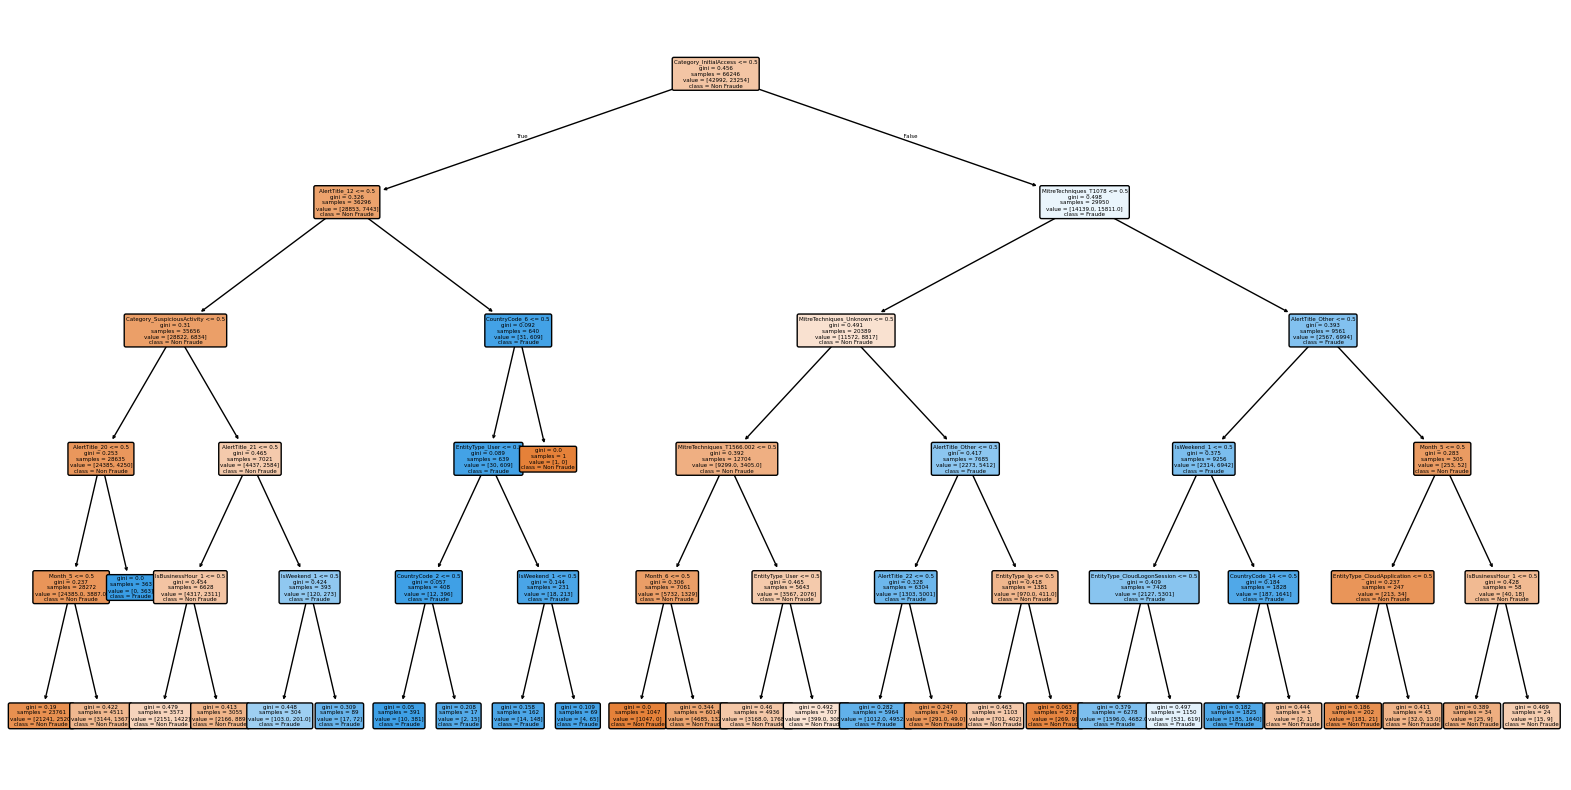

In [25]:
param_grid = {
    'max_depth': list(range(2, 6)),  
    'criterion': ['gini', 'entropy']  
}

grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    scoring='f1',           
    cv=10,                   
    n_jobs=-1
)
grid.fit(X_train, y_train)

# Meilleur modèle
best_clf = grid.best_estimator_
print("Meilleur hyperparamètre :", grid.best_params_)

# --- Prédictions ------
y_pred = best_clf.predict(X_test)

# --- Évaluation ---
print("Accuracy :", accuracy_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))
print("\nMatrice de confusion :\n", confusion_matrix(y_test, y_pred))
print("\nRapport de classification :\n", classification_report(y_test, y_pred, digits=3))

# --- Visualisation de l'arbre ---
plt.figure(figsize=(20,10))
plot_tree(
    best_clf,
    feature_names=X.columns,
    class_names=['Non Fraude', 'Fraude'],
    filled=True,
    rounded=True,
    fontsize=4
)
plt.show()